pip install torch torchvision nltk matplotlib pandas numpy scikit-learn gensim seaborn transformers datasets ipykernel

In [13]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter, defaultdict

import nltk


from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.manifold import TSNE

import gensim.downloader as api

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import seaborn as sns
from datasets import load_dataset

In [14]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /home/arman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/arman/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [15]:
print(torch.cuda.get_device_name(0))
torch.cuda.is_available()


NVIDIA GeForce RTX 3050 6GB Laptop GPU


True

# часть 1

In [16]:
dataset = load_dataset("imdb")

train_data = dataset['train']
test_data = dataset['test']

print(train_data[0])

Using the latest cached version of the dataset since imdb couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at /home/arman/.cache/huggingface/datasets/imdb/plain_text/0.0.0/e6281661ce1c48d982bc483cf8a173c1bbeb5d31 (last modified on Sun May  3 06:12:00 2026).


{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [17]:
stop_words = set(stopwords.words('english'))


def preprocess_text(text):
    text = text.lower()

    # удаление пунктуации
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    tokens = text.split()

    # удаление стоп-слов
    tokens = [word for word in tokens if word not in stop_words]

    return ' '.join(tokens)

In [18]:
for i in range(3):
    original = train_data[i]['text']
    processed = preprocess_text(original)

    print('=' * 80)
    print('ОРИГИНАЛ:')
    print(original[:500])

    print('\nПОСЛЕ ОБРАБОТКИ:')
    print(processed[:500])

ОРИГИНАЛ:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent

ПОСЛЕ ОБРАБОТКИ:
rented curious yellow video store controversy surrounded first released also heard first seized u customs ever tried enter country therefore fan films considered controversial really see br br plot centered around young swedish drama student named lena wants learn everything life particular wants focus attentions making sort documentary average swede thought certain political issues vietnam war race issues united states asking politicians ordinary denizens stockholm 

In [19]:
X_train = [preprocess_text(text) for text in train_data['text']]
y_train = train_data['label']

X_test = [preprocess_text(text) for text in test_data['text']]
y_test = test_data['label']

In [20]:
vectorizer = TfidfVectorizer(max_features=10000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(25000, 10000)


In [21]:
feature_names = np.array(vectorizer.get_feature_names_out())

for class_id in [0, 1]:
    class_vectors = X_train_tfidf[np.array(y_train) == class_id]

    mean_tfidf = np.asarray(class_vectors.mean(axis=0)).flatten()

    top_indices = mean_tfidf.argsort()[-20:][::-1]

    print(f'\nКласс {class_id}')

    for idx in top_indices:
        print(feature_names[idx], round(mean_tfidf[idx], 4))


Класс 0
br 0.1055
movie 0.0589
film 0.0425
one 0.0292
bad 0.0286
like 0.0277
even 0.0226
good 0.0219
would 0.0211
really 0.02
time 0.0187
see 0.0169
acting 0.0168
plot 0.0166
story 0.0166
could 0.0165
movies 0.0163
much 0.0161
make 0.0161
get 0.0161

Класс 1
br 0.092
movie 0.0453
film 0.0442
one 0.0284
great 0.0231
good 0.0223
like 0.0217
story 0.0205
well 0.0193
see 0.0188
time 0.018
really 0.0172
love 0.0165
also 0.0163
best 0.0161
would 0.0152
people 0.0148
first 0.0144
life 0.0144
show 0.0141


In [22]:
clf = LogisticRegression(max_iter=1000)

clf.fit(X_train_tfidf, y_train)

predictions = clf.predict(X_test_tfidf)

In [23]:
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1:', f1)

Accuracy: 0.8832
Precision: 0.8830161522469214
Recall: 0.88344
F1: 0.8832280252739343


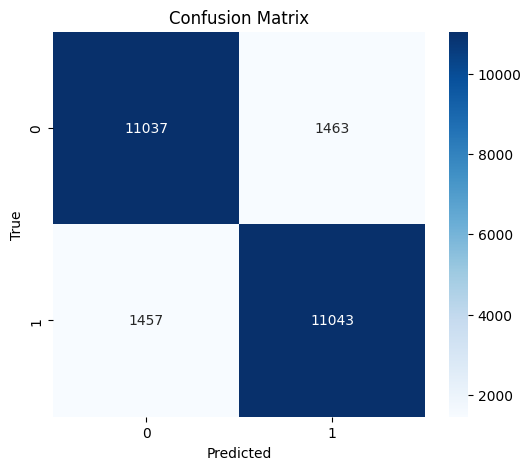

In [24]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

plt.show()

In [25]:
errors = []

for text, true_label, pred_label in zip(test_data['text'], y_test, predictions):
    if true_label != pred_label:
        errors.append((text, true_label, pred_label))

print('Количество ошибок:', len(errors))

Количество ошибок: 2920


In [26]:
for i in range(5):
    text, true_label, pred_label = errors[i]

    print('=' * 80)
    print('Истинная метка:', true_label)
    print('Предсказание:', pred_label)
    print('\nТекст:')
    print(text[:1000])

Истинная метка: 0
Предсказание: 1

Текст:
First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other action guys (Segal and Dolph) have thought about putting out the past few years. Van Damme is good in the movie, the movie is only worth watching to Van Damme fans. It is not as good as Wake of Death (which i highly recommend to anyone of likes Van Damme) or In hell but, in my opinion it's worth watching. It has the same type of feel to it as Nowhere to Run. Good fun stuff!
Истинная метка: 0
Предсказание: 1

Текст:
Blind Date (Columbia Pictures, 1934), was a decent film, but I have a few issues with this film. First of all, I don't fault the actors in this film at all, but more or less, I have a problem with the script. Also, I understand that this film 

# часть 2

In [27]:
model = api.load('glove-wiki-gigaword-100')

[==================================================] 100.0% 128.1/128.1MB downloaded


In [28]:
words = ['king', 'computer', 'music', 'doctor', 'school']

for word in words:
    print('=' * 60)
    print('Слово:', word)

    neighbors = model.most_similar(word, topn=5)

    for neighbor, score in neighbors:
        print(neighbor, round(score, 4))

Слово: king
prince 0.7682
queen 0.7508
son 0.7021
brother 0.6986
monarch 0.6978
Слово: computer
computers 0.8752
software 0.8373
technology 0.7642
pc 0.7366
hardware 0.729
Слово: music
musical 0.8128
songs 0.7978
dance 0.7897
pop 0.7863
recording 0.7651
Слово: doctor
physician 0.7673
nurse 0.7522
dr. 0.7175
doctors 0.7081
patient 0.7074
Слово: school
college 0.8848
schools 0.8358
elementary 0.8156
students 0.803
student 0.7812


In [29]:
result = model.most_similar(
    positive=['king', 'woman'],
    negative=['man'],
    topn=5
)

print(result)

[('queen', 0.7698540687561035), ('monarch', 0.6843381524085999), ('throne', 0.6755736470222473), ('daughter', 0.6594556570053101), ('princess', 0.6520534157752991)]


In [30]:
word_groups = {
    'animals': ['cat', 'dog', 'lion', 'tiger', 'wolf', 'fox', 'rabbit', 'horse'],
    'countries': ['france', 'germany', 'italy', 'china', 'japan', 'india', 'canada', 'brazil'],
    'professions': ['doctor', 'teacher', 'engineer', 'lawyer', 'nurse', 'scientist', 'pilot', 'chef'],
    'emotions': ['happy', 'sad', 'angry', 'fear', 'joy', 'love', 'hate', 'surprise']
}

vectors = []
labels = []
words_all = []

for group, words in word_groups.items():
    for word in words:
        if word in model:
            vectors.append(model[word])
            labels.append(group)
            words_all.append(word)

vectors = np.array(vectors)

In [31]:
tsne = TSNE(n_components=2, random_state=42, perplexity=5)

vectors_2d = tsne.fit_transform(vectors)

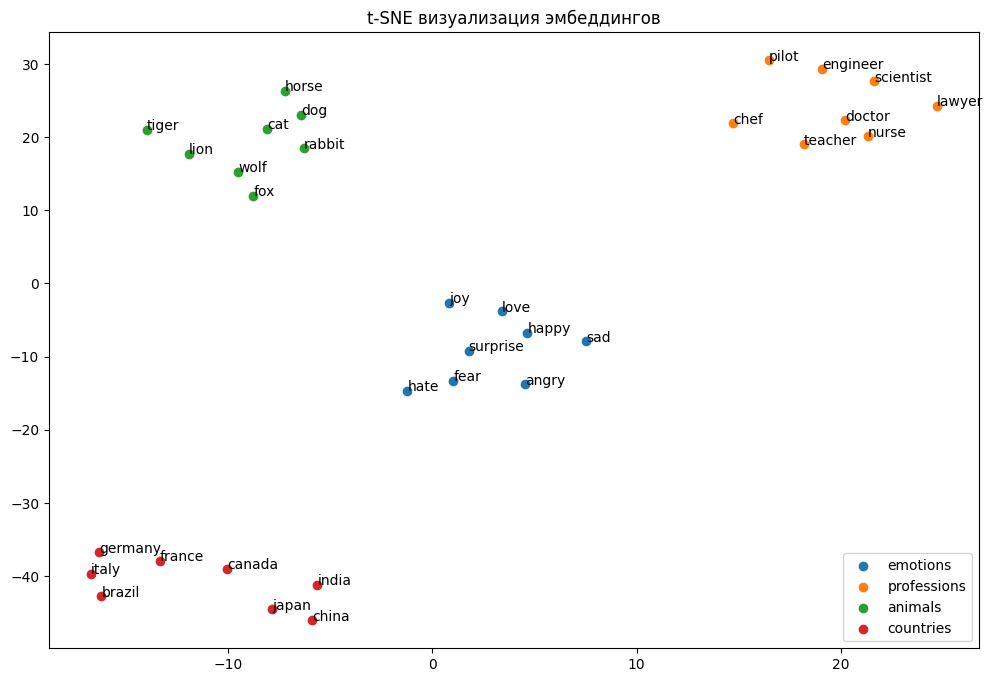

In [32]:
plt.figure(figsize=(12, 8))

for group in set(labels):
    indices = [i for i, label in enumerate(labels) if label == group]

    plt.scatter(
        vectors_2d[indices, 0],
        vectors_2d[indices, 1],
        label=group
    )

for i, word in enumerate(words_all):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))

plt.legend()
plt.title('t-SNE визуализация эмбеддингов')
plt.show()

In [33]:
EMBEDDING_SIZE = 100


def average_embedding(text):
    words = text.split()

    vectors = []

    for word in words:
        if word in model:
            vectors.append(model[word])

    if len(vectors) == 0:
        return np.zeros(EMBEDDING_SIZE)

    return np.mean(vectors, axis=0)

In [34]:
X_train_avg = np.array([average_embedding(text) for text in X_train])
X_test_avg = np.array([average_embedding(text) for text in X_test])

In [35]:
clf_emb = LogisticRegression(max_iter=1000)

clf_emb.fit(X_train_avg, y_train)

pred_emb = clf_emb.predict(X_test_avg)

In [36]:
acc_emb = accuracy_score(y_test, pred_emb)

print('Accuracy (average embeddings):', acc_emb)

Accuracy (average embeddings): 0.79772


# часть 3

In [37]:
MAX_VOCAB = 20000
MAX_LEN = 200
EMBEDDING_DIM = 100

In [38]:
word_counter = Counter()

for text in X_train:
    word_counter.update(text.split())

most_common = word_counter.most_common(MAX_VOCAB - 2)

In [39]:
word2idx = {
    '<PAD>': 0,
    '<UNK>': 1
}

for idx, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = idx

In [40]:
def encode_text(text):
    tokens = text.split()

    encoded = []

    for token in tokens[:MAX_LEN]:
        encoded.append(word2idx.get(token, 1))

    while len(encoded) < MAX_LEN:
        encoded.append(0)

    return encoded

In [41]:
X_train_encoded = np.array([encode_text(text) for text in X_train])
X_test_encoded = np.array([encode_text(text) for text in X_test])

In [42]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [43]:
train_dataset = TextDataset(X_train_encoded, y_train)
test_dataset = TextDataset(X_test_encoded, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [44]:
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_matrix=None, freeze=False):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, EMBEDDING_DIM)

        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
            self.embedding.weight.requires_grad = not freeze

        self.fc1 = nn.Linear(EMBEDDING_DIM, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.embedding(x)

        # GlobalAveragePooling
        x = x.mean(dim=1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

In [45]:
embedding_matrix = np.random.normal(
    scale=0.6,
    size=(len(word2idx), EMBEDDING_DIM)
)

for word, idx in word2idx.items():
    if word in model:
        embedding_matrix[idx] = model[word]

In [49]:
def train_model(model_nn, train_loader, test_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)

    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        model_nn.train()

        total_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            outputs = model_nn(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        model_nn.eval()

        preds = []
        true = []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model_nn(X_batch)

                predicted = torch.argmax(outputs, dim=1)

                preds.extend(predicted.numpy())
                true.extend(y_batch.numpy())
    return train_losses, test_accuracies

In [50]:
random_model = TextClassifier(len(word2idx))

random_losses, random_accs = train_model(
    random_model,
    train_loader,
    test_loader,
    epochs=5
)

In [51]:
glove_model = TextClassifier(
    len(word2idx),
    embedding_matrix=embedding_matrix,
    freeze=True
)

glove_losses, glove_accs = train_model(
    glove_model,
    train_loader,
    test_loader,
    epochs=5
)